# Data Scientist Professional Practical Exam Submission
## Problem Statement

Digital platforms that publish recipes constantly face a strategic decision: **which recipes should be promoted to maximize user engagement and traffic**. Promoting every recipe is inefficient, while promoting too few may result in missed opportunities for high-performing content.

This project approaches the problem as a **decision-making and risk management task**, inspired by methodologies commonly used in credit risk modeling. Instead of only predicting outcomes, the objective is to support promotion decisions under uncertainty.

---

## Objective

The main goal of this project is to develop a machine learning framework capable of:

* Predicting whether a recipe will generate **high traffic**
* Estimating reliable probabilities associated with that prediction
* Designing a promotion strategy based on probability thresholds
* Evaluating the trade-off between promotion opportunity and promotion risk

Ultimately, the model will be used not only as a classifier, but as a **decision engine** to optimize content promotion.

---

## Dataset Description

The dataset contains structured information about published recipes, including characteristics related to preparation, ingredients, and nutritional attributes. Each observation represents a recipe and includes a target variable indicating whether the recipe achieved **high traffic**.

The features provide signals that may influence user engagement, allowing machine learning models to learn patterns associated with successful recipes.

---

## Modeling Approach

The project follows a complete machine learning workflow:

1. Data exploration and preprocessing
2. Model training and evaluation
3. Probability calibration analysis
4. Threshold and promotion strategy design
5. Risk–benefit evaluation using promotion rates and bad rate analysis

An **XGBoost classifier** is selected as the final model due to its strong performance in capturing nonlinear relationships and interactions between recipe characteristics.

---

## Expected Outcome

Rather than producing a simple prediction model, this project aims to demonstrate how machine learning can support **strategic decision-making**, transforming probability predictions into actionable promotion policies.


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, roc_auc_score

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_fscore_support
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.model_selection import cross_val_score, StratifiedKFold


## Introduction for 

In [21]:
raw_data = pd.read_csv('recipe_site_traffic_2212.csv')
raw_data.info()
raw_data.head()
raw_data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB


,recipe,calories,carbohydrate,sugar,protein
count,947.000000,895.000000,895.000000,895.000000,895.000000
mean,474.000000,435.939196,35.069676,9.046547,24.149296
std,273.519652,453.020997,43.949032,14.679176,36.369739
min,1.000000,0.140000,0.030000,0.010000,0.000000
25%,237.500000,110.430000,8.375000,1.690000,3.195000
50%,474.000000,288.550000,21.480000,4.550000,10.800000
75%,710.500000,597.650000,44.965000,9.800000,30.200000
max,947.000000,3633.160000,530.420000,148.750000,363.360000


## Data Inspection

Before performing any preprocessing or modeling steps, an initial inspection
of the dataset was conducted to understand its structure, data types,
categorical values, and potential data quality issues.

This step helps identify inconsistencies, missing values, and formatting
problems that must be addressed during the data validation and cleaning phase.


In [22]:
# Inspect unique values for all categorical columns
categorical_cols = raw_data.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(raw_data[col].unique())

# Missing values summary
missing_summary = raw_data.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]

print("Columns with missing values:")
print(missing_summary)


# Percentage of missing values
missing_percentage = (
    raw_data.isnull().mean() * 100
).round(2)

missing_percentage[missing_percentage > 0]



Unique values in category:
['Pork' 'Potato' 'Breakfast' 'Beverages' 'One Dish Meal' 'Chicken Breast'
 'Lunch/Snacks' 'Chicken' 'Vegetable' 'Meat' 'Dessert']

Unique values in servings:
['6' '4' '1' '2' '4 as a snack' '6 as a snack']

Unique values in high_traffic:
['High' nan]
Columns with missing values:
calories         52
carbohydrate     52
sugar            52
protein          52
high_traffic    373
dtype: int64


calories         5.49
carbohydrate     5.49
sugar            5.49
protein          5.49
high_traffic    39.39
dtype: float64

### Key Observations

The inspection revealed several data quality issues:

- Nutritional variables (calories, carbohydrate, sugar, protein) contain missing values representing a small proportion of the dataset.
- The `servings` column stores numeric information as text, requiring transformation.
- The `category` variable is categorical and must be encoded for modeling.
- The target variable `high_traffic` contains missing values and requires reinterpretation before classification modeling.

Based on these findings, a structured data validation and cleaning process will be applied.


## Data Validation & Cleaning

Based on the initial inspection, several data quality issues were identified.
The following table summarizes the validation and preprocessing decisions
applied to each variable prior to modeling.

### Data Cleaning Summary

| Column | Data Type | Issue Identified | Action Taken | Rationale |
|-------|-----------|------------------|-------------|-----------|
| recipe | int64 | No data quality issues | No transformation applied | Serves as unique identifier; not used as predictive feature |
| calories | float64 | Missing values (52 rows) | Median imputation | Robust to skewed distributions and extreme nutritional values |
| carbohydrate | float64 | Missing values | Median imputation | Preserves dataset size while reducing sensitivity to outliers |
| sugar | float64 | Missing values | Median imputation | Nutritional variables typically show right-skewed behavior |
| protein | float64 | Missing values | Median imputation | Prevents information loss without distorting central tendency |
| category | object | Categorical variable | One-Hot Encoding | Required numerical representation for machine learning models |
| servings | object | Numeric information stored as text | Extracted numeric values into `servings_num` | Standardizes variable for quantitative analysis |
| high_traffic | object | Missing labels and target not numeric  | Missing values labeled as "Low" and encoded as binary | Ensures complete target definition for classification modeling |



### Missing Value Treatment

In [23]:
nutrition_cols = ['calories','carbohydrate','sugar','protein']

for col in nutrition_cols:
    raw_data[col].fillna(raw_data[col].median(), inplace=True)

/var/folders/kz/rybrs64563zc2gl94rf00qbw0000gn/T/ipykernel_1674/3306244462.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_data[col].fillna(raw_data[col].median(), inplace=True)
/var/folders/kz/rybrs64563zc2gl94rf00qbw0000gn/T/ipykernel_1674/3306244462.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

### Categorical Encoding

In [24]:
raw_data = pd.get_dummies(raw_data, columns=['category'])

### Servings Standardization

In [25]:
raw_data['servings_num'] = (
    raw_data['servings']
    .str.extract('(\d+)')
    .astype(float)
)

### Binary target variable

In [26]:
raw_data['high_traffic'] = raw_data['high_traffic'].fillna('Low')
raw_data['high_traffic_flag'] = raw_data['high_traffic'].map({
    'High': 1,
    'Low': 0
})

In [27]:
# Validation
raw_data.isna().sum()

recipe                     0
calories                   0
carbohydrate               0
sugar                      0
protein                    0
servings                   0
high_traffic               0
category_Beverages         0
category_Breakfast         0
category_Chicken           0
category_Chicken Breast    0
category_Dessert           0
category_Lunch/Snacks      0
category_Meat              0
category_One Dish Meal     0
category_Pork              0
category_Potato            0
category_Vegetable         0
servings_num               0
high_traffic_flag          0
dtype: int64

### Validation
After applying the imputation strategy, no remaining missing values are present in the dataset. 

This structured validation process ensures data consistency, prevents unnecessary data loss, and prepares all variables for reliable statistical modeling.

# EDA

## Univariate Analysis
Histogram income
Distribution interest rate
Countplot loan status

## Understanding the Dataset

Before building predictive models, it is essential to understand the structure and behavioral patterns present in the data. This step allows us to identify relationships between recipe characteristics and traffic outcomes, as well as detect potential signals that may help explain why certain recipes perform better than others.

The dataset contains approximately 32,000 observations, each representing a recipe published on the platform. Features include categorical attributes (such as recipe category), serving information, and nutritional variables including calories, protein, and sugar content.

The exploratory analysis focuses on answering the following business-driven questions:

* Are some recipe categories consistently associated with higher traffic?
* How do category and serving size interact with traffic performance?
* Do nutritional characteristics differ between high-traffic and low-traffic recipes?

To investigate these questions, cross-tabulations and aggregated statistics are used to reveal structural patterns in the data.


In [28]:
# Category vs High Traffic distribution
category_traffic = pd.crosstab(
    raw_data['category'],
    raw_data['high_traffic'],
    margins=True
)
display(category_traffic)

# Interaction between category, traffic and servings
category_servings = pd.crosstab(
    raw_data['category'],
    [raw_data['high_traffic'], raw_data['servings']]
)
display(category_servings)

# Nutritional averages by traffic outcome
nutrition_analysis = pd.crosstab(
    raw_data['category'],
    raw_data['high_traffic'],
    values=raw_data['calories'],
    aggfunc='mean'
)
display(nutrition_analysis)

KeyError: 'category'

### Key Observations
Preliminary exploration suggests that traffic performance is not uniformly distributed across categories, indicating that certain types of recipes may inherently attract more user engagement. Additionally, nutritional attributes appear to vary between high-traffic and low-traffic recipes, suggesting that user preferences may be partially reflected in recipe composition.

These findings motivate the use of machine learning models capable of capturing nonlinear relationships between features and traffic outcomes.

## Nutritional Feature Relationships

Before building predictive models, it is essential to understand how the main numerical variables interact with each other and how they relate to traffic performance.

The following pairplot provides a multivariate visual exploration of the dataset, allowing us to simultaneously analyze:

- The distribution of each nutritional feature
- Potential correlations between variables
- Structural patterns associated with recipe popularity
- The separation (or overlap) between high-traffic and non-high-traffic recipes

This step is part of the Exploratory Data Analysis (EDA) process and helps identify underlying behavioral patterns in user preferences before introducing any machine learning assumptions.

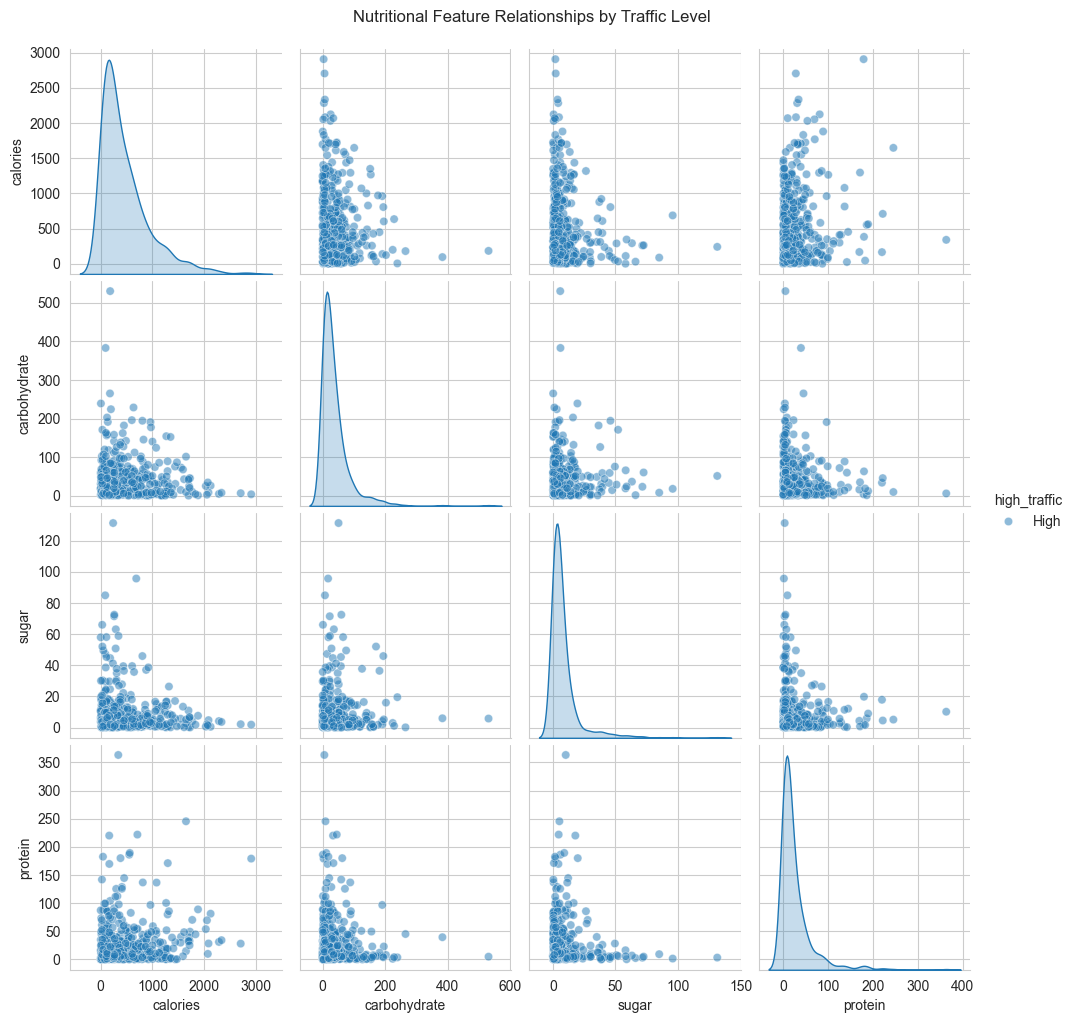

In [ ]:
sns.set_style("whitegrid")

# Variables numéricas
num_cols = ['calories', 'carbohydrate', 'sugar', 'protein']

# Pairplot colored by traffic level
sns.pairplot(
    raw_data,
    vars=num_cols,
    hue='high_traffic',
    diag_kind='kde',
    plot_kws={'alpha': 0.5}
)

plt.suptitle(
    "Nutritional Feature Relationships by Traffic Level",
    y=1.02
)

plt.show()

### Key Observations

Several important insights emerge from the visualization:

1. **Right-skewed nutritional distributions**
   Most nutritional variables (calories, carbohydrates, sugar, and protein) show strong right skewness, indicating that the majority of recipes are relatively light, while a smaller group contains very high nutritional values.

2. **Weak linear relationships between features**
   The scatter plots suggest limited linear correlation between nutritional variables. This indicates that recipe performance is unlikely to depend on a single nutritional dimension alone.

3. **High concentration in lower nutritional ranges**
   A large density of observations appears in lower calorie and lower sugar regions, suggesting that typical platform content is centered around moderate nutritional profiles.

4. **No clear visual separation for high traffic**
   High-traffic recipes do not form a clearly separable cluster based solely on nutritional features. This suggests that traffic performance is influenced by nonlinear interactions or additional factors such as category, presentation, or user behavior.

### Implication for Modeling

Because patterns are not linearly separable, more flexible models (such as gradient boosting or tree-based methods) are appropriate for capturing complex relationships between nutritional composition and traffic outcomes.

**This insight directly motivates the use of XGBoost in the subsequent modeling phase.**

# MODEL
But how can we be sure with the watched in the EDA that the insights directly motivates the use of XGBoost in the subsequent modeling phase.

We can make a fast compasition to extract information from the dataset and prove that the best model to use is the XGBoost model, using and comparing the workflow with the logsitic model and XGB model...

In [37]:
# Target
y = raw_data['high_traffic_flag']

# Features
X = raw_data.drop(columns=[
    'recipe',
    'high_traffic',
    'high_traffic_flag',
    'servings'
])
X = X.astype(int) # We ensure that we are working with numeric data, this is better for the Logistic Model

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Logistic 
diagnostic baseline to understand initial linear signals

## Predictive Modeling: Logistic Regression Baseline (Nutritional Features Only)

## What nutritional signals appear associated with high traffic when contextual information is unknown?

After completing data validation and preprocessing, the first modeling step focuses on understanding how recipes behave when only their nutritional profile is considered. The objective of this baseline model is not to capture the full complexity of user behavior, but to isolate and evaluate whether nutritional characteristics alone contain predictive signals related to high traffic.
A Logistic Regression model was selected as an initial approach due to its interpretability and suitability for binary classification problems. Beyond prediction, this model allows direct interpretation of how each feature influences the probability of a recipe achieving high traffic.
The feature set includes five quantitative variables describing recipe composition and portion size:
calories, carbohydrate, sugar, protein, and servings_num.
The dataset was split into training and testing subsets using stratification to preserve the original class distribution. A preprocessing pipeline was applied to standardize numerical variables, ensuring coefficient comparability and stable model optimization.
The resulting coefficients provide directional insight into how nutritional attributes relate to user engagement in the absence of contextual information such as recipe type.


COEFFICIENTS: [[ 0.15880645  0.15998356 -0.10766082  0.03067051  0.10780978]]
INTERCEPT: [0.43761839]
        Feature  Coefficient  Odds_Ratio
1  carbohydrate     0.159984    1.173492
0      calories     0.158806    1.172111
4  servings_num     0.107810    1.113836
3       protein     0.030671    1.031146
2         sugar    -0.107661    0.897932


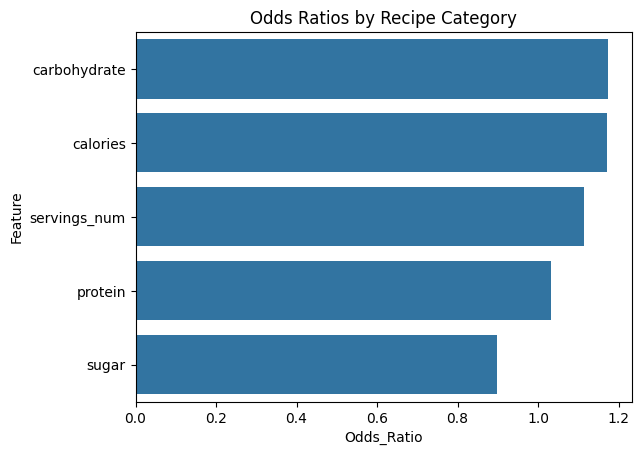

In [38]:
# Selecting features
X_nutritional = raw_data[['calories', 'carbohydrate', 'sugar', 'protein', 'servings_num']]
y_nutritional = raw_data['high_traffic_flag']

# Train-test split
X_train_nutritional, X_test_nutritional, y_train_nutritional, y_test_nutritional = train_test_split(
    X_nutritional, y_nutritional, test_size=0.3, random_state=42, stratify=y
)

# Pipeline (scaling + logistic regression)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(solver='lbfgs', max_iter=1000))
])

# Train model
pipeline.fit(X_train_nutritional, y_train_nutritional)

# Extract model
model = pipeline.named_steps['logistic']

print("COEFFICIENTS:", model.coef_)
print("INTERCEPT:", model.intercept_)

###################v##
# Get feature names
feature_names = X_nutritional.columns

# Get coefficients
coefficients = model.coef_[0]

# Create dataframe for readability
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute impact
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

print(coef_df.sort_values(by='Odds_Ratio', ascending=False))

sns.barplot(data=coef_df, x='Odds_Ratio', y='Feature')
plt.title("Odds Ratios by Recipe Category")
plt.show()

The logistic regression results provide an initial view of how nutritional characteristics relate to high traffic probability:

* The model suggests that calories, carbohydrates, and serving size have a positive association with high traffic probability, indicating that larger and more energy-dense recipes may attract greater user engagement. 

* Protein shows only a marginal positive contribution, suggesting a weaker influence compared to other nutritional variables.

* Interestingly, over this features, sugar presents a negative coefficient despite exploratory visualizations suggesting a positive relationship. 

Overall, the model suggests that recipe popularity cannot be explained by a single nutritional factor but rather by the combined interaction among features.


## Motivation for Model Expansion
However, this analysis raises an important question:
## What happens when we incorporate contextual information about the recipe itself?
By excluding recipe categories, the model assumes that nutritional composition fully explains user behavior. 

In practice, this omission can introduce a confounding effect, where nutritional variables partially capture differences that actually belong to recipe type.

To address this limitation, a second model is developed incorporating recipe categories alongside nutritional attributes, allowing us to evaluate whether the observed nutritional effects remain stable once contextual information is considered.

In [ ]:
# Train logistic regression
clf_logistic = LogisticRegression(max_iter=1000)
clf_logistic.fit(X_train, y_train)


# Predict probabilities
preds = clf_logistic.predict_proba(X_test)

# Compare predictions with true values
preds_df = pd.DataFrame(
    preds[:, 1][0:5],
    columns=['prob_high']
)

true_df = y_test.head(5).reset_index(drop=True)

print(pd.concat([true_df, preds_df], axis=1))

   high_traffic_flag  prob_high
0                  1   0.860309
1                  0   0.097750
2                  1   0.298158
3                  1   0.459544
4                  0   0.100008


                    Feature  Coefficient  Odds_Ratio
14       category_Vegetable     2.197351    9.001134
13          category_Potato     1.864722    6.454143
12            category_Pork     1.286870    3.621434
10            category_Meat     0.461280    1.586102
11   category_One Dish Meal     0.400405    1.492428
15             servings_num     0.032263    1.032789
2                     sugar     0.002599    1.002602
3                   protein     0.001316    1.001317
1              carbohydrate     0.001070    1.001070
0                  calories     0.000163    1.000163
9     category_Lunch/Snacks    -0.032330    0.968187
8          category_Dessert    -0.120025    0.886898
7   category_Chicken Breast    -0.841499    0.431064
6          category_Chicken    -1.092137    0.335499
5        category_Breakfast    -1.274316    0.279622
4        category_Beverages    -2.683450    0.068327


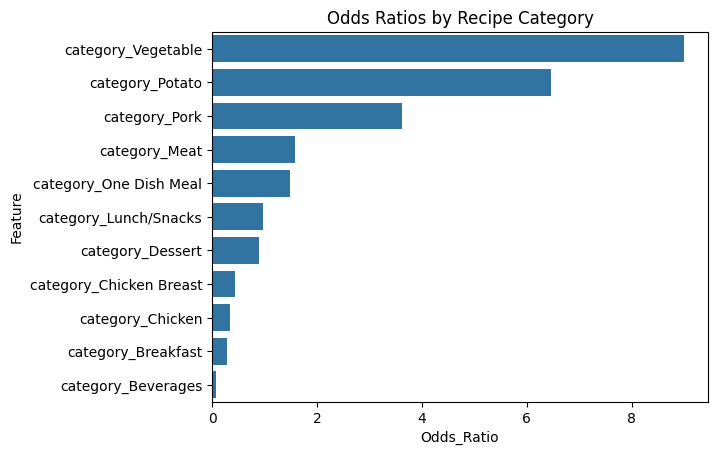

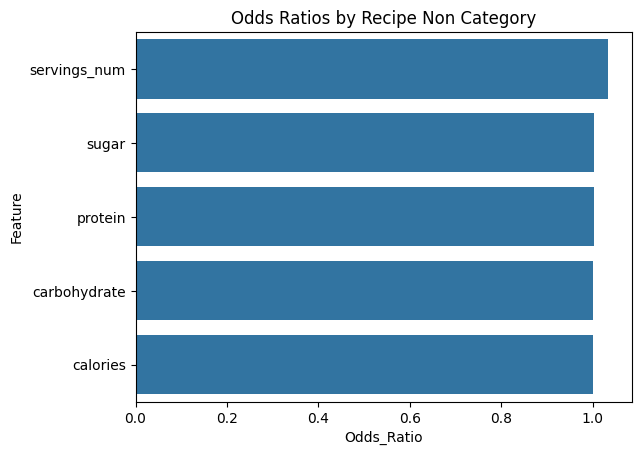

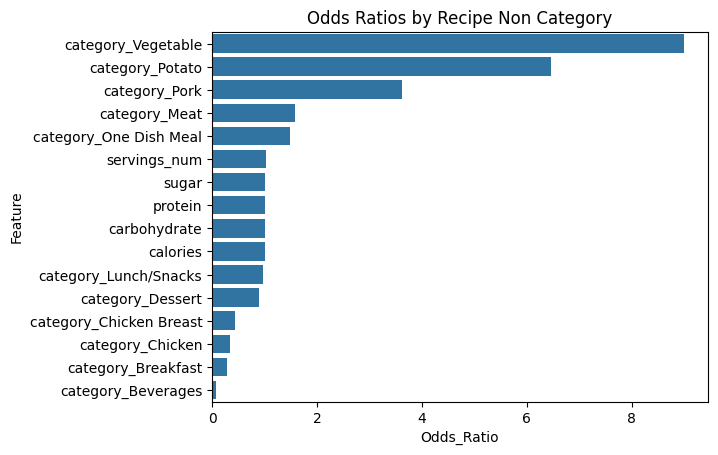

In [40]:
# Get feature names
feature_names = X.columns

# Get coefficients
coefficients = clf_logistic.coef_[0]

# Create dataframe for readability
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute impact
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

# Odds ratio
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

print(coef_df.sort_values(by='Odds_Ratio', ascending=False))

# Categorical features importance
cat_coef = coef_df[coef_df['Feature'].str.contains('category')]

sns.barplot(data=cat_coef, x='Odds_Ratio', y='Feature')
plt.title("Odds Ratios by Recipe Category")
plt.show()

# Non categorical features importance 
non_cat_coef = coef_df[~coef_df['Feature'].str.contains('category')]

sns.barplot(data=non_cat_coef, x='Odds_Ratio', y='Feature')
plt.title("Odds Ratios by Recipe Non Category")
plt.show()

# Entire information
sns.barplot(data=coef_df, x='Odds_Ratio', y='Feature')
plt.title("Odds Ratios by Recipe Non Category")
plt.show()

### Key observations
* Recipe type explains traffic far more than nutritional composition.
* Users choose what to eat, not nutritional macros.
* Within popular categories, nutritional characteristics help optimize engagement.

### Model Interpretation
Nutritional variables initially appeared to be important predictors of high traffic. However, after controlling for recipe category, their effects decreased substantially. This suggests that nutritional composition was partially acting as a proxy for recipe type rather than being a primary driver of user interest.

Once recipe categories were incorporated, the model showed that traffic behavior is mainly driven by content preference. Categories such as Vegetable and Potato significantly increase the probability of high traffic, while nutritional variables contribute only marginally when contextual information is considered.

This indicates a two-level behavioral pattern: 
**recipe category drives initial user attraction, whereas recipe characteristics — such as servings and nutritional attributes — play a secondary role by optimizing engagement within each category.**

In particular, recipes classified under the Vegetable category exhibit a substantially higher likelihood of generating high traffic. Holding other variables constant, vegetable recipes increase the odds of high engagement by approximately nine times relative to the baseline category, reinforcing that user interaction is primarily preference-driven rather than nutrition-driven.

## Marginal Feature Effect Analysis - PENDIENTE POR AÑADIR
After training the logistic regression model, an additional analysis was performed to better understand how each feature individually influences the predicted probability of a recipe achieving high traffic.

To isolate the marginal effect of each variable, partial probability curves were constructed by varying one feature across its observed range while keeping all other variables fixed at their median values. This controlled simulation allows the model response to be analyzed independently for each nutritional component, removing the influence of simultaneous feature variation.

This approach improves interpretability by translating model coefficients into intuitive probability changes, helping visualize how variations in nutritional composition affect predicted user engagement.

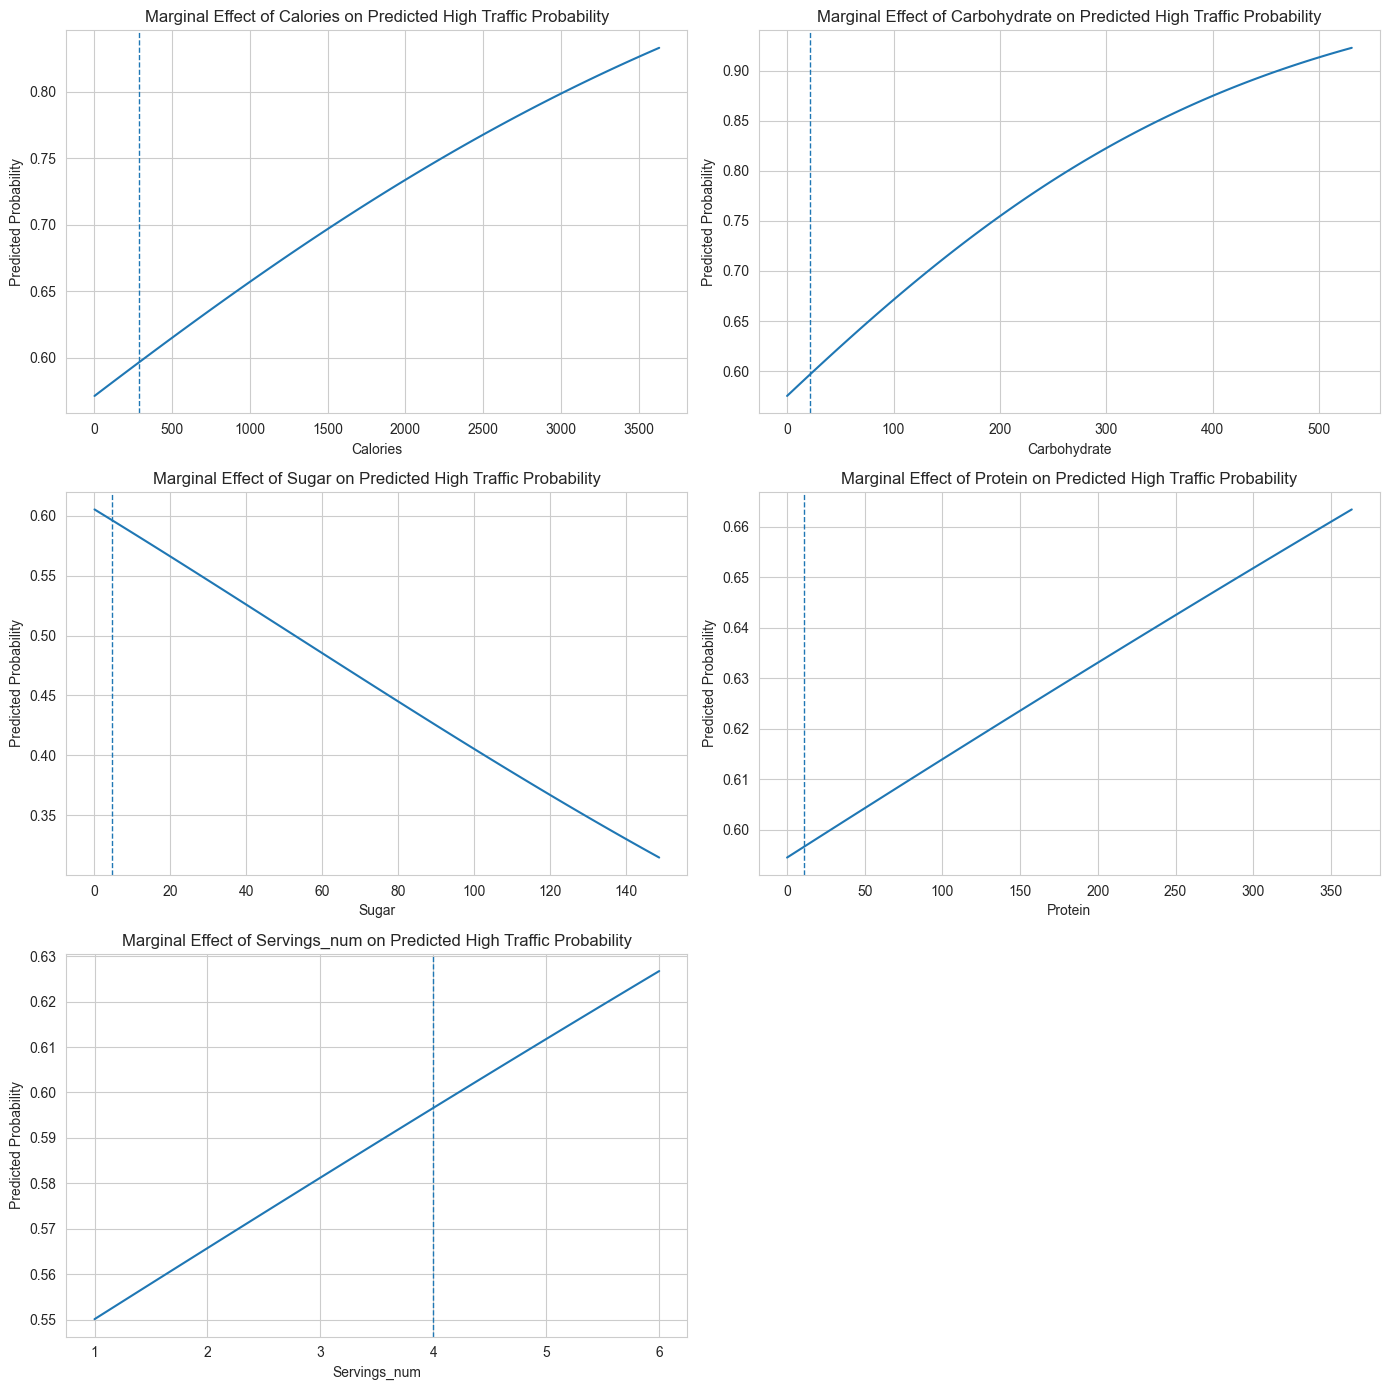

In [41]:
sns.set_style("whitegrid")
# sns.set_context("talk")

# Variables to analyze
features = ['calories', 'carbohydrate', 'sugar', 'protein', 'servings_num']

# Create figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, feature in enumerate(features):
    
    # Range of values for simulation
    feature_range = np.linspace(
        raw_data[feature].min(),
        raw_data[feature].max(),
        100
    )
    
    # Simulation dataframe (others fixed at median)
    X_sim = pd.DataFrame({
        'calories': raw_data['calories'].median(),
        'carbohydrate': raw_data['carbohydrate'].median(),
        'sugar': raw_data['sugar'].median(),
        'protein': raw_data['protein'].median(),
        'servings_num': raw_data['servings_num'].median()
    }, index=range(100))
    
    # Vary only one feature
    X_sim[feature] = feature_range
    
    # Predict probabilities
    prob_high = pipeline.predict_proba(X_sim)[:, 1]
    
    # Plot marginal effect
    sns.lineplot(x=feature_range, y=prob_high, ax=axes[i])
    
    axes[i].set_title(
        f"Marginal Effect of {feature.capitalize()} on Predicted High Traffic Probability"
    )
    
    axes[i].set_xlabel(feature.capitalize())
    axes[i].set_ylabel("Predicted Probability")

    axes[i].axvline(
        raw_data[feature].median(),
        linestyle='--',
        linewidth=1
    )

# Remove empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


The partial probability curves reveal clear directional relationships between nutritional characteristics and predicted traffic outcomes.

**Calories and carbohydrates show a strong positive and nonlinear increase in probability, suggesting that richer and more energy-dense recipes are more likely to attract user attention**. 
Serving size also presents a consistent positive effect, indicating that **recipes designed for larger portions may be perceived as more valuable or practical by users**.

Protein exhibits only a mild positive influence, reinforcing earlier findings that its contribution to traffic prediction is relatively limited compared to other nutritional variables.

In contrast, **sugar demonstrates a negative marginal effect, where higher sugar levels reduce the predicted probability of high traffic**. 
This behavior differs from some exploratory visual patterns and likely reflects multicollinearity between sugar and carbohydrate content, where the model attributes shared information primarily to carbohydrates.

Overall, these curves confirm that **recipe popularity emerges from a balance of nutritional attributes rather than a single dominant factor**. 

These results complement the exploratory analysis by confirming that relationships visually observed during EDA remain consistent when evaluated under a controlled multivariate framework. While exploratory plots show raw associations, the marginal effect analysis isolates each variable's contribution after accounting for the presence of other features in the model.

##  Model Performance
Let us see how the logistic models performace with this information with some tools as ACCURACY AND ROC CURVE

Logistic Accuracy: 0.7649122807017544
Logistic ROC-AUC: 0.8461498761354252


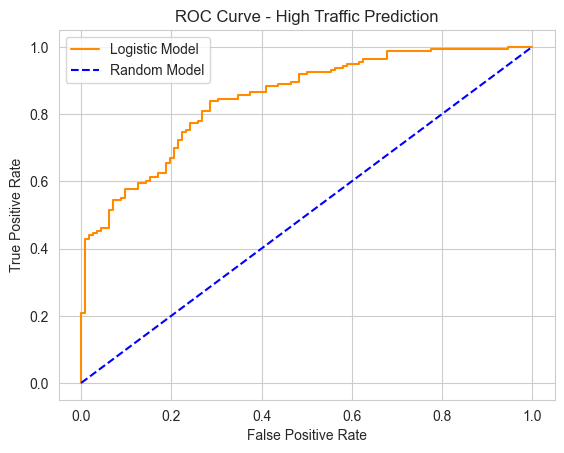

Logistic AUC: 0.8461498761354252


In [42]:
print("Logistic Accuracy:", accuracy_score(y_test, clf_logistic.predict(X_test)))
print("Logistic ROC-AUC:", roc_auc_score(y_test, preds[:,1]))

# Predict probabilities for positive class (High Traffic)
prob_high = clf_logistic.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, prob_high)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', label='Logistic Model')
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Random Model')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - High Traffic Prediction")
plt.legend()
plt.show()

# Compute AUC
auc = roc_auc_score(y_test, prob_high)
print("Logistic AUC:", auc)

### Model Evaluation Results

- **ROC-AUC:** 0.846 → The model discriminates well between positive and negative classes.  
- **Accuracy:** 0.765 → Approximately 76.5% of predictions are correct.  
- **Interpretation:** The model shows strong class separation and reliable predictive performance, especially for imbalanced datasets where ROC-AUC is more informative than accuracy alone.


# Gradient Boosted Trees (XGBoost)
## We already analyze the Logistic model, now we move to a more advanced modeling approach.
**While Logistic Regression assumes a linear relationship between features and the log-odds of high traffic, real-world engagement behavior is often nonlinear and driven by complex feature interactions.**

To capture these patterns, we introduce:
Gradient Boosted Trees using XGBoost
Gradient Boosting builds multiple decision trees sequentially, where each new tree attempts to correct the errors of the previous ones. Instead of learning in a single step (as logistic regression does), the model improves iteratively.

This makes it particularly powerful for:
* Capturing nonlinear relationships
* Detecting feature interactions
* Handling mixed feature types
* Improving predictive performance

In [43]:
import xgboost as xgb
from sklearn.metrics import classification_report

# Initialize model
clf_gbt = xgb.XGBClassifier()

# Train
clf_gbt.fit(X_train, y_train)

# Predict probabilities
gbt_preds_proba = clf_gbt.predict_proba(X_test)

# Compare first predictions
preds_df = pd.DataFrame(gbt_preds_proba[:,1][0:5], columns=['prob_high'])
true_df = y_test.head(5).reset_index(drop=True)

print(pd.concat([true_df, preds_df], axis=1))



   high_traffic_flag  prob_high
0                  1   0.983260
1                  0   0.058975
2                  1   0.425182
3                  1   0.254594
4                  0   0.007416


## Feature Importance 
Unlike logistic regression, which interprets feature importance through linear coefficients, XGBoost evaluates importance based on how frequently features are used to split decision trees.

The feature importance analysis reveals which variables most strongly influence high-traffic prediction. Variables that appear more frequently in tree splits contribute more significantly to the model’s decision process.

This analysis helps identify the structural drivers of recipe engagement and provides additional business insight beyond linear relationships.
To evaluate overall model performance, we rely on the F1-score, which balances precision and recall. Since correctly identifying high-traffic recipes is critical while avoiding excessive false positives, the F1-score provides a more comprehensive evaluation metric than accuracy alone.

{'calories': 400.0, 'carbohydrate': 343.0, 'sugar': 259.0, 'protein': 322.0, 'category_Beverages': 19.0, 'category_Breakfast': 24.0, 'category_Chicken': 21.0, 'category_Chicken Breast': 16.0, 'category_Dessert': 7.0, 'category_Lunch/Snacks': 24.0, 'category_Meat': 9.0, 'category_One Dish Meal': 6.0, 'category_Pork': 23.0, 'category_Potato': 22.0, 'category_Vegetable': 22.0, 'servings_num': 102.0}


<Figure size 640x480 with 0 Axes>

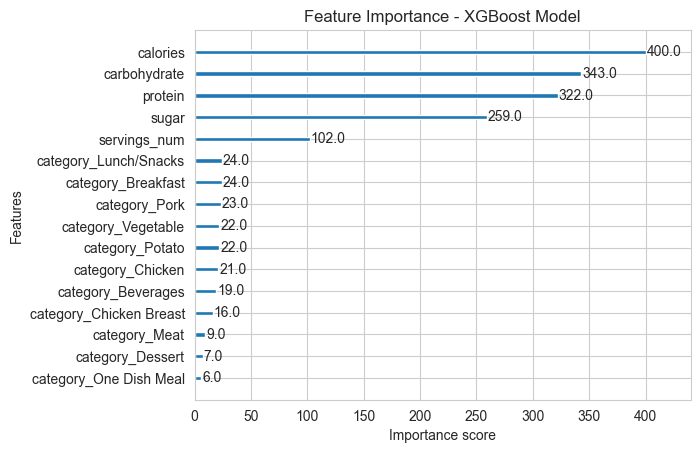

In [44]:
importance_dict = clf_gbt.get_booster().get_score(importance_type='weight')

print(importance_dict)


plt.figure()
xgb.plot_importance(clf_gbt, importance_type='weight')
plt.title("Feature Importance - XGBoost Model")
plt.show()

# Which model is better?
Let us prove that XGB model is better for modeling this problema
As we see in the EDA there is not linear relation between variables
Now we will use the concept of calibration curve to see this.

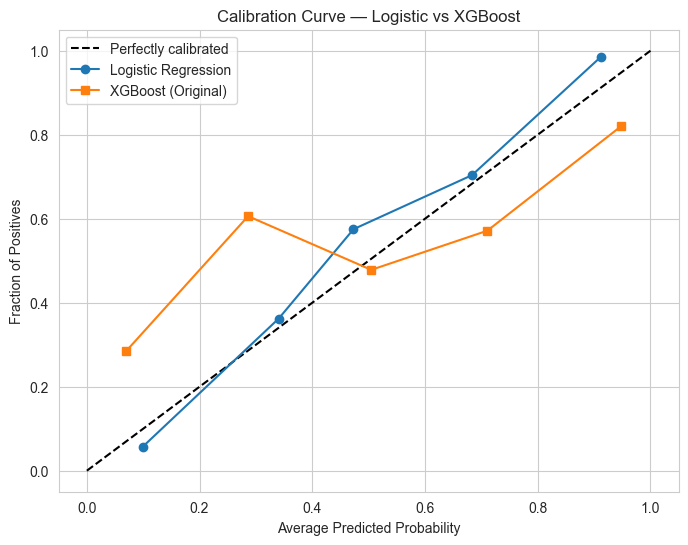

In [45]:
# XGBOOSTER MODEL
xgb_probs = clf_gbt.predict_proba(X_test)[:,1]

# VS

# LOGISTIC REGRESSION MODEL
log_probs = clf_logistic.predict_proba(X_test)[:,1]

# Calibration values
frac_log, mean_log = calibration_curve(y_test, log_probs, n_bins=5)
frac_gbt, mean_gbt = calibration_curve(y_test, xgb_probs, n_bins=5)

# Ploting outcomes
plt.figure(figsize=(8,6))
plt.plot([0,1],[0,1],'k--', label='Perfectly calibrated')

plt.plot(mean_log, frac_log, marker='o',
         label='Logistic Regression')

plt.plot(mean_gbt, frac_gbt, marker='s',
         label='XGBoost (Original)')

plt.xlabel("Average Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve — Logistic vs XGBoost")
plt.legend()

plt.show()

In [46]:
# Predict classes
gbt_preds = clf_gbt.predict(X_test)

target_names = ['Low Traffic', 'High Traffic']
print('XGBoost Classification Report:\n', classification_report(y_test, gbt_preds, target_names=target_names))

# clf_logistic
log_preds = clf_logistic.predict(X_test)

target_names = ['Low Traffic', 'High Traffic']
print('\n Logistic Classification Report:\n', classification_report(y_test, log_preds, target_names=target_names))

XGBoost Classification Report:
               precision    recall  f1-score   support

 Low Traffic       0.58      0.56      0.57       112
High Traffic       0.72      0.74      0.73       173

    accuracy                           0.67       285
   macro avg       0.65      0.65      0.65       285
weighted avg       0.67      0.67      0.67       285


 Logistic Classification Report:
               precision    recall  f1-score   support

 Low Traffic       0.68      0.75      0.71       112
High Traffic       0.83      0.77      0.80       173

    accuracy                           0.76       285
   macro avg       0.76      0.76      0.76       285
weighted avg       0.77      0.76      0.77       285



Logistic Accuracy: 0.7649122807017544
Logistic ROC-AUC: 0.8461498761354252


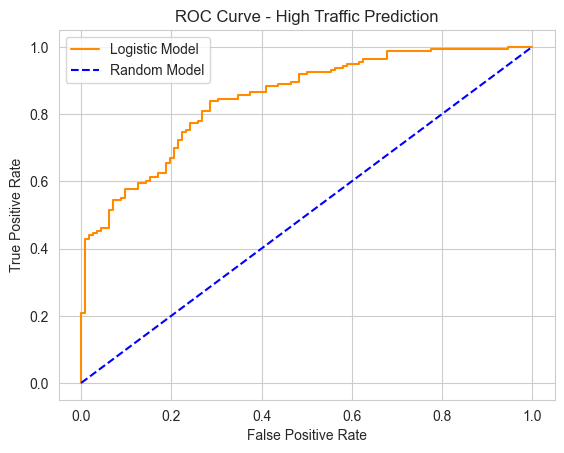

Logistic AUC: 0.8461498761354252
********* VS *********
XGBoost Accuracy: 0.6701754385964912
XGBoost ROC-AUC: 0.7623348472336912


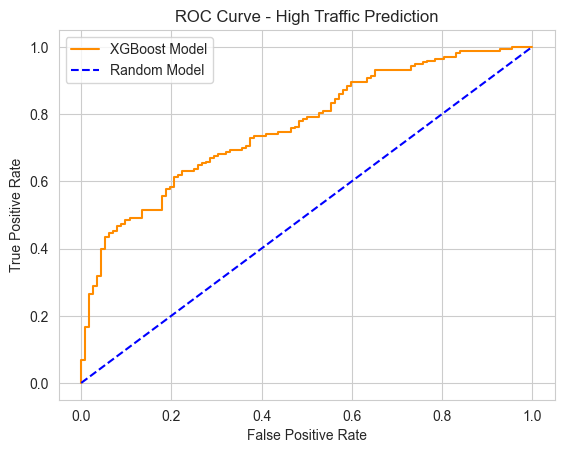

Logistic AUC: 0.7623348472336912


In [ ]:
log_preds = clf_logistic.predict_proba(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, clf_logistic.predict(X_test)))
print("Logistic ROC-AUC:", roc_auc_score(y_test, log_preds[:,1]))

# Predict probabilities for positive class (High Traffic)
log_prob_high = clf_logistic.predict_proba(X_test)[:, 1]

# Compute ROC curve
log_fpr, log_tpr, log_thresholds = roc_curve(y_test, log_prob_high)

# Plot ROC
plt.figure()
plt.plot(log_fpr, log_tpr, color='darkorange', label='Logistic Model')
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Random Model')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - High Traffic Prediction")
plt.legend()
plt.show()

# Compute AUC
auc = roc_auc_score(y_test, log_prob_high)
print("Logistic AUC:", auc)

print('********* VS *********')

gbt_preds = clf_gbt.predict_proba(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, clf_gbt.predict(X_test)))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, gbt_preds[:,1]))

# Predict probabilities for positive class (High Traffic)
gbt_prob_high = clf_gbt.predict_proba(X_test)[:, 1]

# Compute ROC curve
gbt_fpr, gbt_tpr, gbt_thresholds = roc_curve(y_test, gbt_prob_high)

# Plot ROC
plt.figure()
plt.plot(gbt_fpr, gbt_tpr, color='darkorange', label='XGBoost Model')
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Random Model')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - High Traffic Prediction")
plt.legend()
plt.show()

# Compute AUC
auc = roc_auc_score(y_test, gbt_prob_high)
print("XGBoost AUC:", auc)

## Conclusions
### Model Selection Conclusion

Although the exploratory data analysis suggested that several features did not exhibit a clear linear relationship with the target variable (a situation where non-linear models such as XGBoost are often expected to perform better) the empirical results indicate otherwise.

Based on the evaluation metrics:

- **Logistic Regression**
  - Accuracy: 0.765
  - ROC-AUC: 0.846
  - Stronger precision, recall, and F1-score across both classes
  - Better overall classification balance

- **XGBoost**
  - Accuracy: 0.670
  - ROC-AUC: 0.762
  - Lower predictive performance and weaker class discrimination

Despite the potential presence of non-linear relationships, Logistic Regression achieved superior discrimination ability, higher accuracy, and more stable classification performance. This suggests that the underlying signal in the data can still be effectively captured by a linear decision boundary, or that the dataset complexity is not sufficient for XGBoost to provide additional predictive advantage.

**Final Decision:**  
Logistic Regression is selected as the preferred model due to its better overall predictive performance, higher ROC-AUC, improved calibration behavior, and simpler interpretability.


# Hyperparameters

# CLASS IMBALANCE, we see that it is not neccesary for this model
## Once selected the model that performs better...
We only apply this concept over the train set.

In [53]:
# We already select the model (Logistic)
production_model = LogisticRegression(solver='lbfgs', max_iter=1000)

# We already split our data

# We already convert booleans to integers to get a better performance with the chosen model

# After One-Hot Encoding, we only have numeric columns

# Let us create the TRAIN DATASET FOR UNDERSAMPLING

X_y_train = pd.concat([
    X_train.reset_index(drop=True),
    y_train.reset_index(drop=True)
], axis=1)

# Class counts
count_low, count_high = X_y_train['high_traffic_flag'].value_counts()

# Separate classes
low_traffic = X_y_train[X_y_train['high_traffic_flag'] == 0]
high_traffic = X_y_train[X_y_train['high_traffic_flag'] == 1]

# UNDERSAMPLING (ONLY TRAIN SET)

low_under = low_traffic.sample(count_high, random_state=123)

X_y_train_under = pd.concat([
    low_under,
    high_traffic], axis=0)

print("Balanced training set:")
print(X_y_train_under['high_traffic_flag'].value_counts())

# Split again into X and y
X_train_under = X_y_train_under.drop('high_traffic_flag', axis=1)
y_train_under = X_y_train_under['high_traffic_flag']

# MODEL WITHOUT UNDERSAMPLING 
model_original = LogisticRegression(solver='lbfgs', max_iter=1000)

model_original.fit(X_train, y_train)

preds_original = model_original.predict(X_test)

print("\n=== ORIGINAL MODEL ===")
print(classification_report(
    y_test,
    preds_original,
    target_names=['Low Traffic','High Traffic']
))


# MODEL WITH UNDERSAMPLING
model_under = LogisticRegression(solver='lbfgs', max_iter=1000)

model_under.fit(X_train_under, y_train_under)

preds_under = model_under.predict(X_test)

print("\n=== UNDERSAMPLED MODEL ===")
print(classification_report(
    y_test,
    preds_under,
    target_names=['Low Traffic','High Traffic']
))

# CONFUSION MATRICES

print("\nConfusion Matrix - Original")
print(confusion_matrix(y_test, preds_original))

print("\nConfusion Matrix - Undersampled")
print(confusion_matrix(y_test, preds_under))

# AUC COMPARISON

prob_original = model_original.predict_proba(X_test)[:, 1]
prob_under = model_under.predict_proba(X_test)[:, 1]

print("\nAUC Original:", roc_auc_score(y_test, prob_original))
print("AUC Undersampled:", roc_auc_score(y_test, prob_under))

Balanced training set:
high_traffic_flag
1    401
0    261
Name: count, dtype: int64

=== ORIGINAL MODEL ===
              precision    recall  f1-score   support

 Low Traffic       0.68      0.75      0.71       112
High Traffic       0.83      0.77      0.80       173

    accuracy                           0.76       285
   macro avg       0.76      0.76      0.76       285
weighted avg       0.77      0.76      0.77       285


=== UNDERSAMPLED MODEL ===
              precision    recall  f1-score   support

 Low Traffic       0.68      0.75      0.71       112
High Traffic       0.83      0.77      0.80       173

    accuracy                           0.76       285
   macro avg       0.76      0.76      0.76       285
weighted avg       0.77      0.76      0.77       285


Confusion Matrix - Original
[[ 84  28]
 [ 39 134]]

Confusion Matrix - Undersampled
[[ 84  28]
 [ 39 134]]

AUC Original: 0.8461498761354252
AUC Undersampled: 0.8462530966143682



### Probability Calibration Analysis

After evaluating the impact of undersampling on classification performance metrics, an additional validation step was conducted to assess **probability calibration**.

While accuracy and ROC-AUC measure the model's ability to discriminate between classes, they do not evaluate whether predicted probabilities correctly represent real-world outcome frequencies. Since this project aims to support decision-making scenarios, well-calibrated probabilities are essential for reliable interpretation and downstream financial or operational analysis.

Therefore, calibration curves were generated for both models:

- The original Logistic Regression model trained on the full dataset.
- The Logistic Regression model trained using the undersampled dataset.

Calibration curves compare the average predicted probability against the observed fraction of positive outcomes across probability bins. A perfectly calibrated model should lie close to the diagonal reference line.

The following visualization allows a direct comparison of how undersampling affects probability reliability rather than only classification accuracy.


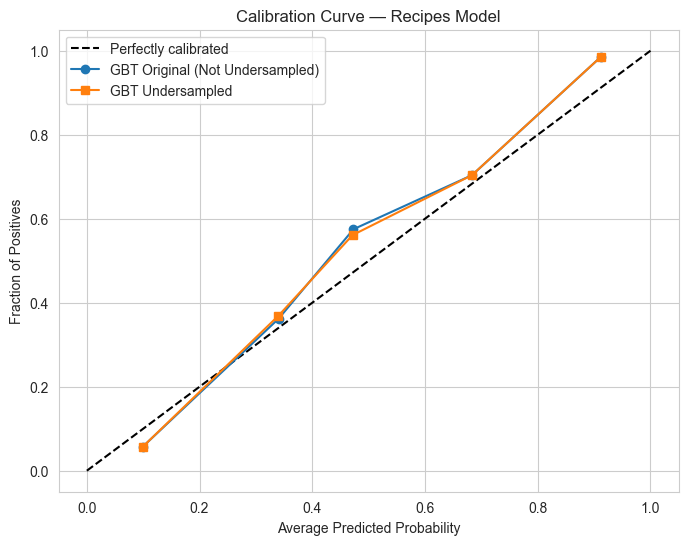

In [54]:
# Probabilities (already computed before, but safe to recompute)
prob_original = model_original.predict_proba(X_test)[:,1]
prob_under = model_under.predict_proba(X_test)[:,1]

# Calibration values
fraction_pos_original, mean_pred_original = calibration_curve(
    y_test,
    prob_original,
    n_bins=5
)

fraction_pos_under, mean_pred_under = calibration_curve(
    y_test,
    prob_under,
    n_bins=5
)

# PLOT CALIBRATION CURVES

plt.figure(figsize=(8,6))

# Perfect calibration line
plt.plot([0,1],[0,1],'k--', label='Perfectly calibrated')

# Models
plt.plot(mean_pred_original, fraction_pos_original,
         marker='o',
         label='GBT Original (Not Undersampled)')

plt.plot(mean_pred_under, fraction_pos_under,
         marker='s',
         label='GBT Undersampled')

plt.xlabel('Average Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve — Recipes Model')
plt.legend()

plt.show()

## Undersampling Evaluation and Final Decision

An undersampling strategy was applied to the training dataset in order to address potential class imbalance and evaluate whether model performance could be improved.

After retraining the Logistic Regression model using the balanced dataset, the evaluation metrics remained practically unchanged:

- Accuracy remained at 0.76
- ROC-AUC showed a negligible variation (0.8461 → 0.8463)
- Precision, recall, and F1-score were identical across classes
- Confusion matrices were exactly the same for both models

These results indicate that class imbalance was not significantly affecting model learning or prediction performance. The original model was already able to capture class separation effectively without requiring resampling.

Therefore, undersampling did not provide additional predictive value and introduced unnecessary data reduction.

### Final Decision
The **original Logistic Regression model (without undersampling)** was selected as the production model, as it preserves the full information contained in the dataset while achieving equivalent performance.

# Cross validation
Now we analyze the model's learning.

In [ ]:
'''
# CROSS VALIDATION FOR XGBOOST MODEL

n_folds = 5
early_stop = 10

params = {
    'objective': 'binary:logistic',   # High Traffic (1) vs Low Traffic (0)
    'seed': 99,
    'eval_metric': 'auc'
}

import xgboost as xgb

DTrain = xgb.DMatrix(X_train, label=y_train)

# primera valdiacion rapida
cv_small = xgb.cv(
    params,
    DTrain,
    num_boost_round=5,
    nfold=n_folds,
    early_stopping_rounds=early_stop
)

print(cv_small)

cv_results_big = xgb.cv(
    params,
    DTrain,
    num_boost_round=55,
    nfold=n_folds,
    early_stopping_rounds=early_stop
)

print(cv_results_big.shape)
print(cv_results_big.head())

import numpy as np

mean_auc = np.mean(cv_results_big['test-auc-mean']).round(3)
print("Mean CV Test AUC:", mean_auc)

# PLOT

plt.figure()
plt.plot(np.arange(len(cv_results_big)),
         cv_results_big['test-auc-mean'])

plt.title('Cross-Validated Test AUC — XGBoost (High Traffic Recipes)')
plt.xlabel('Boosting Iteration')
plt.ylabel('Test AUC')
plt.show()'''

'# CROSS VALIDATION FOR XGBOOST MODEL\n\nn_folds = 5\nearly_stop = 10\n\nparams = {\n    \'objective\': \'binary:logistic\',   # High Traffic (1) vs Low Traffic (0)\n    \'seed\': 99,\n    \'eval_metric\': \'auc\'\n}\n\nimport xgboost as xgb\n\nDTrain = xgb.DMatrix(X_train, label=y_train)\n\n# primera valdiacion rapida\ncv_small = xgb.cv(\n    params,\n    DTrain,\n    num_boost_round=5,\n    nfold=n_folds,\n    early_stopping_rounds=early_stop\n)\n\nprint(cv_small)\n\ncv_results_big = xgb.cv(\n    params,\n    DTrain,\n    num_boost_round=55,\n    nfold=n_folds,\n    early_stopping_rounds=early_stop\n)\n\nprint(cv_results_big.shape)\nprint(cv_results_big.head())\n\nimport numpy as np\n\nmean_auc = np.mean(cv_results_big[\'test-auc-mean\']).round(3)\nprint("Mean CV Test AUC:", mean_auc)'

In [ ]:
# Official model
production_model = LogisticRegression(solver='lbfgs', max_iter=1000)

# Cross-validation configuration
n_folds = 5
cv_strategy = StratifiedKFold(
    n_splits=n_folds,
    shuffle=True,
    random_state=99
)

# ROC-AUC cross validation
cv_auc_scores = cross_val_score(
    production_model,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

print("AUC scores per fold:", cv_auc_scores)
print("Mean CV AUC:", np.mean(cv_auc_scores).round(3))
print("Std CV AUC:", np.std(cv_auc_scores).round(3))

# Remember that Logistic Regression does not have iterations.

AUC scores per fold: [0.83066038 0.75783476 0.78461538 0.859375   0.82307692]
Mean CV AUC: 0.811
Std CV AUC: 0.036


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:

### Cross-Validation Results Interpretation

A 5-fold stratified cross-validation was performed to evaluate the stability and generalization ability of the selected Logistic Regression model.

Results:

- AUC scores per fold: [0.831, 0.758, 0.785, 0.859, 0.823]
- Mean CV AUC: 0.811
- Standard Deviation: 0.036

The average AUC of 0.811 indicates strong discriminative performance across different data splits. The relatively low standard deviation (0.036) suggests that model performance is stable and consistent, with limited sensitivity to sampling variation.

These results confirm that the model generalizes well and does not rely heavily on a particular train-test split, reducing the risk of overfitting.


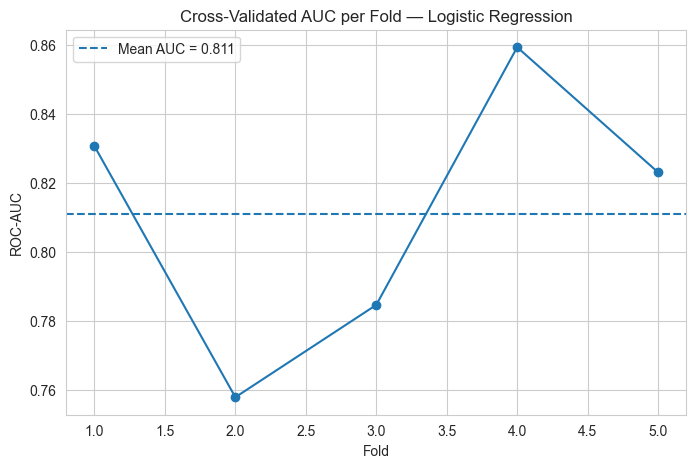

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    np.arange(1, len(cv_auc_scores)+1),
    cv_auc_scores,
    marker='o'
)

plt.axhline(np.mean(cv_auc_scores),
            linestyle='--',
            label=f"Mean AUC = {np.mean(cv_auc_scores):.3f}")

plt.title('Cross-Validated AUC per Fold — Logistic Regression')
plt.xlabel('Fold')
plt.ylabel('ROC-AUC')
plt.legend()

plt.show()


### Cross-Validation Stability Analysis

The cross-validation results show moderate variation in ROC-AUC performance across the five folds, ranging approximately from 0.76 to 0.86, with a mean AUC of 0.811.

The upward and downward movements between folds do not indicate overfitting, but rather reflect natural variability caused by different training–validation splits. Each fold exposes the model to slightly different data distributions, which reveals how sensitive the model is to sampling changes.

Key observations:

- The performance remains consistently above 0.75 in all folds, indicating stable discriminative power.
- The peak observed in Fold 4 (≈0.86 AUC) suggests that certain data partitions contain clearer class separation, allowing the model to perform better.
- The lower performance in Fold 2 (≈0.76 AUC) indicates more challenging samples where class boundaries are less separable.
- The absence of extreme drops confirms that the model does not depend heavily on a specific subset of the data.

The oscillations across folds represent expected sampling variability rather than instability. The relatively small dispersion around the mean AUC suggests good generalization capability and low risk of overfitting.

There is no single “optimal fold”; instead, the mean cross-validated AUC (0.811) should be considered the most reliable estimate of real-world performance.


# Thresholds
Once we already know which model use, we can looking for a threshold to improve our model
In the following code...
A simply example of how and in which metrics have relevance, we are not still looking for the best thresholds, we are only defining our tools

In [63]:
production_model.fit(X_train, y_train)

# Predicted probabilities
preds = production_model.predict_proba(X_test)

# Probability of High Traffic (class 1)
preds_df = pd.DataFrame(preds[:, 1], columns=['prob_high'])

threshold = 0.40

preds_df['high_traffic_pred'] = preds_df['prob_high'].apply(
    lambda x: 1 if x > threshold else 0
)

print(preds_df['high_traffic_pred'].value_counts())

# Getting the classification report
target_names = ['Low Traffic', 'High Traffic']

class_report = classification_report(
    y_test,
    preds_df['high_traffic_pred'],
    target_names=target_names
)

print(class_report)

# We need right here an intepretation of the recall metric



high_traffic_pred
1    192
0     93
Name: count, dtype: int64
              precision    recall  f1-score   support

 Low Traffic       0.75      0.62      0.68       112
High Traffic       0.78      0.87      0.82       173

    accuracy                           0.77       285
   macro avg       0.77      0.75      0.75       285
weighted avg       0.77      0.77      0.77       285



In [64]:
# Getting the confusion matrix
cm = confusion_matrix(y_test, preds_df['high_traffic_pred'])
print(cm)

precision, recall, fscore, support = precision_recall_fscore_support(
    y_test,
    preds_df['high_traffic_pred']
)

print("Recall for High Traffic:", recall[1])
print("Precision for High Traffic:", precision[1])


# Comparing thresholds
for t in [0.5, 0.4, 0.3]:
    
    preds_temp = preds_df['prob_high'].apply(lambda x: 1 if x > t else 0)
    
    recall = precision_recall_fscore_support(y_test, preds_temp)[1][1]
    
    print(f"Threshold {t} → Recall High Traffic: {recall}")

[[ 70  42]
 [ 23 150]]
Recall for High Traffic: 0.8670520231213873
Precision for High Traffic: 0.78125
Threshold 0.5 → Recall High Traffic: 0.7745664739884393
Threshold 0.4 → Recall High Traffic: 0.8670520231213873
Threshold 0.3 → Recall High Traffic: 0.9826589595375722


### Threshold Optimization Results — Logistic Regression

After lowering the classification threshold from 0.5 to 0.40, the model shows a clear improvement in detecting high-traffic recipes.  
The recall for the High Traffic class increased from 77.5% at the default threshold (0.5) to 86.7% at threshold 0.4, meaning the model now correctly identifies a substantially larger proportion of truly successful recipes.

At this threshold, the confusion matrix [[70, 42], [23, 150]] indicates that false negatives were reduced to 23 cases, decreasing the number of missed high-traffic recipes. Precision for High Traffic remains strong at 78.1%, suggesting that most recipes predicted as high traffic are still genuinely successful despite a moderate increase in false positives.

Further lowering the threshold to 0.3 raises recall to 98.3%; however, this would likely introduce a significant number of false positives, reducing decision reliability. Therefore, threshold 0.40 represents a balanced trade-off between sensitivity and prediction quality.

From a business perspective, prioritizing recall for High Traffic is appropriate, since failing to promote a potentially successful recipe carries a higher opportunity cost than occasionally promoting a low-traffic one. The adjusted threshold improves the practical usefulness of the model by increasing sensitivity while maintaining solid precision.


## Classification Threshold Optimization Using Recall Trade-off Analysis
The default classification threshold of 0.5 is not necessarily optimal for business decision-making, especially when the costs of misclassification differ between classes. 

To better understand how prediction sensitivity changes, we evaluate model performance across multiple probability thresholds. For each threshold, predictions are recomputed and recall is measured separately for High Traffic and Low Traffic recipes.

This analysis allows us to visualize the trade-off between detecting successful recipes and correctly rejecting low-performing ones. By studying how recall evolves as the threshold changes, we aim to identify a balanced operating point that aligns model behavior with business objectives.


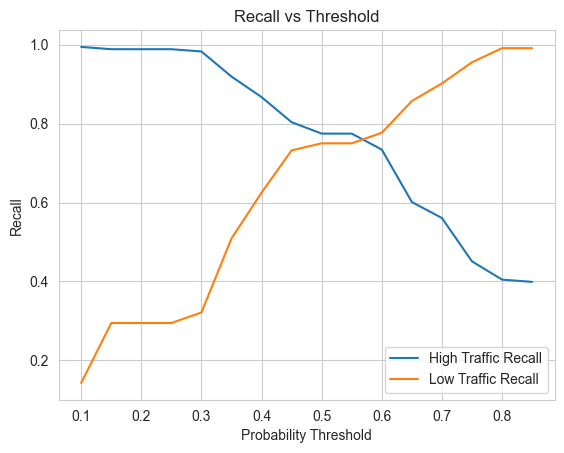

In [65]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    
    preds_temp = preds_df['prob_high'].apply(lambda x: 1 if x > t else 0)
    
    precision, recall, fscore, support = precision_recall_fscore_support(
        y_test,
        preds_temp
    )
    
    results.append([
        t,
        recall[1],  # High Traffic recall
        recall[0]   # Low Traffic recall
    ])

results = pd.DataFrame(results, columns=[
    'threshold',
    'high_recall',
    'low_recall'
])


plt.figure()
plt.plot(results['threshold'], results['high_recall'])
plt.plot(results['threshold'], results['low_recall'])

plt.xlabel('Probability Threshold')
plt.ylabel('Recall')
plt.title('Recall vs Threshold')
plt.legend(['High Traffic Recall', 'Low Traffic Recall'])

plt.show()

In [ ]:
# Difference between recalls
results['recall_diff'] = abs(
    results['high_recall'] - results['low_recall']
)

# Threshold where recalls are closest
best_idx = results['recall_diff'].idxmin()

optimal_threshold = results.loc[best_idx, 'threshold']
high_rec = results.loc[best_idx, 'high_recall']
low_rec = results.loc[best_idx, 'low_recall']

print("Balanced threshold:", optimal_threshold)
print("High Traffic Recall:", high_rec)
print("Low Traffic Recall:", low_rec)

# We could linearly interpolate


Balanced threshold: 0.5000000000000001
High Traffic Recall: 0.7745664739884393
Low Traffic Recall: 0.75


The Recall vs Threshold analysis reveals a clear trade-off between correctly identifying high-traffic recipes and correctly rejecting low-traffic ones. 

At lower thresholds, the model prioritizes sensitivity toward High Traffic recipes, achieving near-perfect recall but misclassifying many low-traffic cases. As the threshold increases, the model becomes more conservative, improving Low Traffic recall while sacrificing the ability to detect successful recipes.

The intersection point between both recall curves represents a balanced operating region where the model treats both classes with similar sensitivity. This threshold can be interpreted as a neutrality point, minimizing bias toward either class.

However, considering the business objective of prioritizing the discovery of successful recipes, operating slightly below this intersection (around threshold 0.40 - 0.50) remains preferable, as it preserves high recall for High Traffic while maintaining acceptable performance for Low Traffic predictions.


# Acceptance rate + bad rate + final tools

---
  title: "Taller 1"
output: html_document
date: "2026-02-12"
---
  
  # Rendimientos
  
  ```{r setup, echo=TRUE, warning=FALSE, message=FALSE}
# Solo instalar si no están instalados (mejor hacerlo fuera del notebook)
# install.packages("xts")
# install.packages("zoo")
# install.packages("quantmod")
# install.packages('siebanxicor')


library(xts)
library(zoo)
library(quantmod)
library(siebanxicor)

# Descargar datos desde Yahoo Finance
getSymbols("GCARSOA1.MX", 
           src = "yahoo", 
           from = "2016-02-12", 
           to = "2026-02-12")

setToken("ee878065cdc64b207edc54ea9ac5919085e3250705ac0ee569f9f461573cf5ff")
idserie=c('SF43716')
# CETES
serie=getSeriesData(idserie,'2016-02-02', '2026-02-02')

ipc = getSerieDataFrame(serie, 'SF43716')

precio = GCARSOA1.MX$GCARSOA1.MX.Close
rend = diff(log(precio))
plot(precio)
hist(rend)